# Part 1 · Learn, implement and verify tabular Q-learning

## Rules

| Requirement or edge case | Implementation |
|---|---|
| Grid and B | Configurable size and delivery target; assessed run is 5×5 with B at displayed (5,5) |
| Lake | Configurable fixed cell; displayed (3,4), internal (2,3), in the main run |
| Movement | Eight actions, all available to the learner; cardinal and diagonal moves each count as one step |
| Lake entry | The agent moves onto the lake and receives **exactly −10**, not −11; the episode continues |
| Ordinary move | −1, including rejected attempts beyond the grid |
| Delivery | Exactly +100, automatically at B while carrying; episode terminates |
| Lake and B overlap | Rejected explicitly so delivery and lake rewards cannot conflict |
| Start and A | Independently sampled from **all** cells, including the lake; no scenarios are silently removed |
| A in the lake | Entering it both collects the item and incurs −10; carrying is retained |
| Start in the lake | No entry reward at reset; the agent can leave immediately |
| Start=A | Main run follows literal entry: leave and re-enter to collect |
| A=B | Entering B collects and delivers in that same move |
| Alternative reset convention | `pickup_on_reset=True` collects immediately when starting on A; checked separately |
| Boundaries | Reject the entire invalid move; staying on an edge lake via an invalid action is not another entry |
| Diagonal corner rule | Only the destination cell matters; neighbouring lake cells do not block a diagonal |
| Training cap | Truncates exploration without changing a nonterminal state into successful delivery |


The learner is not forbidden from entering the lake. Avoidance must be learned from reward. Lake position is fixed during a run, so it does not add an observation dimension. If the lake moved between episodes, its location would need to be observed and encoded.

Scenario accounting: with the main strict-entry convention, 600 scenarios have A outside the lake and can be solved without any lake entry after reset. The other 25 have A in the lake and require one entry. Of the 600, 576 also have their start outside the lake. All 625 remain in the delivery denominator.

1×1 exception: literal entry is impossible with no valid moves. Use pickup_on_reset=True and lake=None for an immediate zero-move task. A lake cannot coincide with the only delivery cell.


## Imports and experiment settings

In [1]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import time
import json
from collections import deque
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

N = 5
B = (N - 1, N - 1)
# For N=5 this gives internal (2,3), displayed (3,4).
LAKE = (N // 2, min(N - 1, N // 2 + 1)) if N >= 3 else ((0, N - 1) if N == 2 else None)
SEED = 0
PICKUP_ON_RESET = False
MAX_EPISODES = 19_000
ALPHA = 1.0
GAMMA = 0.95
EPSILON_START = 1.0
EPSILON_END = 0.1
DECAY_EPISODES = 15_000
EVALUATE_EVERY = 1_000
ASSESSMENT_LIMIT = 10

print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__, '| Matplotlib:', matplotlib.__version__)
print('Internal B:', B, '| Display B:', tuple(v + 1 for v in B))
print('Internal lake:', LAKE, '| Display lake:', None if LAKE is None else tuple(v + 1 for v in LAKE))


Python: 3.12.10
NumPy: 2.5.3 | Matplotlib: 3.11.1
Internal B: (4, 4) | Display B: (5, 5)
Internal lake: (2, 3) | Display lake: (3, 4)


## Actions, observations and rewards

An action is an index into the eight row/column changes. For example, `(-1,1)` moves up-right. The observation remains `(row, column, A_row, A_column, carrying)`, where carrying is 0 or 1. B and the lake are fixed environment settings; A is explicitly observed from the start.

The reward is

$$
r=\begin{cases}
100 & \text{successful delivery},\\
-10 & \text{valid movement enters the lake},\\
-1 & \text{otherwise}.
\end{cases}
$$

The lake is not a terminal failure, and it does not remove an item already being carried. An item in the lake still has to be collected. There is no pickup bonus. Both lake entry and delivery have their stated **total** reward, replacing the ordinary −1 for that move.

Why a detour can help: from displayed (2,3), collect at A=(4,5), then deliver at B=(5,5). The direct three-move route enters the lake and receives rewards [-10, -1, 100]. A four-move route avoiding it receives [-1, -1, -1, 100]. At gamma=0.95 their discounted returns are 79.3 and 82.885 respectively, so the detour is more valuable.

In [3]:
ACTIONS = ((-1, 0), (1, 0), (0, -1), (0, 1),
           (-1, -1), (-1, 1), (1, -1), (1, 1))
ACTION_NAMES = ('up', 'down', 'left', 'right',
                'up-left', 'up-right', 'down-left', 'down-right')

for action, (name, change) in enumerate(zip(ACTION_NAMES, ACTIONS)):
    print(f'{action}: {name:10s} changes position by {change}')

0: up         changes position by (-1, 0)
1: down       changes position by (1, 0)
2: left       changes position by (0, -1)
3: right      changes position by (0, 1)
4: up-left    changes position by (-1, -1)
5: up-right   changes position by (-1, 1)
6: down-left  changes position by (1, -1)
7: down-right changes position by (1, 1)


## Implement the environment

A `class` is a blueprint for independent environments. Each instance has its own position, A, carrying flag, episode counters and random generator. `self` refers to that instance. `__init__` sets it up. A method is a function attached to the instance.

Read this cell by method:

| Method | Responsibility |
|---|---|
| `__init__` | Validate settings and create episode variables |
| `validate_cell` | Check coordinates and convert NumPy integers to ordinary integers |
| `observation` | Return a fresh, immutable five-element tuple |
| `reset` | Set explicit test positions or sample random training positions |
| `step` | Apply one action, process events, return feedback |

The learner cannot access a hidden optimal route here. The environment only enforces the task's rules.

In `step`, movement happens first, pickup second, delivery third, and the training cap last. This ordering handles A=B and delivery on the last permitted move correctly. `terminated` means delivered; `truncated` means the practical step cap was reached without delivery.


In [4]:
class TransportGrid:
    def __init__(self, n=5, target=None, max_steps=100, seed=0,
                 pickup_on_reset=True, lake=None):
        if not isinstance(n, int) or isinstance(n, bool) or n < 1:
            raise ValueError('n must be a positive integer.')
        if not isinstance(max_steps, int) or max_steps < 1:
            raise ValueError('max_steps must be a positive integer.')
        self.n = n
        self.target = self.validate_cell((n - 1, n - 1) if target is None else target)
        self.lake = None if lake is None else self.validate_cell(lake)
        if self.lake == self.target:
            raise ValueError('The lake and delivery target must be different cells.')
        self.max_steps = max_steps
        self.pickup_on_reset = pickup_on_reset
        if n == 1 and not pickup_on_reset:
            raise ValueError('A 1x1 grid needs pickup on reset: no entry move exists.')
        self.rng = np.random.default_rng(seed)
        self.position = (0, 0)
        self.pickup = (0, 0)
        self.carrying = False
        self.terminated = False
        self.truncated = False
        self.steps = 0
        self.lake_entries = 0

    def validate_cell(self, cell):
        if len(cell) != 2:
            raise ValueError('A cell needs exactly two coordinates.')
        if any(not isinstance(v, (int, np.integer)) or isinstance(v, bool) for v in cell):
            raise ValueError('Coordinates must be integers.')
        row, col = map(int, cell)
        if not (0 <= row < self.n and 0 <= col < self.n):
            raise ValueError('Cell is outside the grid.')
        return row, col

    def observation(self):
        return (*self.position, *self.pickup, int(self.carrying))

    def reset(self, start=None, pickup=None):
        self.position = self.validate_cell(self.rng.integers(self.n, size=2) if start is None else start)
        self.pickup = self.validate_cell(self.rng.integers(self.n, size=2) if pickup is None else pickup)
        self.carrying = self.pickup_on_reset and self.position == self.pickup
        self.terminated = self.carrying and self.position == self.target
        if self.terminated:
            self.carrying = False
        self.truncated = False
        self.steps = 0
        self.lake_entries = 0
        return self.observation()

    def step(self, action):
        if self.terminated or self.truncated:
            raise RuntimeError('Reset before stepping an ended episode.')
        if isinstance(action, bool) or not isinstance(action, (int, np.integer)) or not 0 <= action < len(ACTIONS):
            raise ValueError('Action must be an integer from 0 to 7.')
        dr, dc = ACTIONS[action]
        row, col = self.position
        candidate = (row + dr, col + dc)
        valid = all(0 <= v < self.n for v in candidate)
        if valid:
            self.position = candidate
        self.steps += 1
        entered_lake = valid and self.position == self.lake
        if entered_lake:
            self.lake_entries += 1
        picked_up = valid and not self.carrying and self.position == self.pickup
        if picked_up:
            self.carrying = True
        self.terminated = self.carrying and self.position == self.target
        if self.terminated:
            reward = 100.0
        elif entered_lake:
            reward = -10.0
        else:
            reward = -1.0
        if self.terminated:
            self.carrying = False
        self.truncated = self.steps >= self.max_steps and not self.terminated
        info = {'picked_up': picked_up, 'invalid_move': not valid,
                'success': self.terminated, 'entered_lake': entered_lake}
        return self.observation(), reward, self.terminated, self.truncated, info


## Check the rules before learning

In [5]:
def check_environment():
    env = TransportGrid(n=5, pickup_on_reset=False)

    # Every action must reach its expected neighbour from the centre.
    expected = ((1, 2), (3, 2), (2, 1), (2, 3),
                (1, 1), (1, 3), (3, 1), (3, 3))
    for action, destination in enumerate(expected):
        env.reset(start=(2, 2), pickup=(4, 0))
        env.step(action)
        assert env.position == destination

    # Out-of-bounds diagonal: reject the whole move, not just one component.
    env.reset(start=(0, 0), pickup=(2, 2))
    _, reward, done, cut, info = env.step(5)
    assert env.position == (0, 0) and env.steps == 1
    assert reward == -1 and info['invalid_move'] and not done and not cut

    # Enter B empty-handed: no delivery.
    env.reset(start=(4, 3), pickup=(0, 0))
    _, reward, done, _, _ = env.step(3)
    assert reward == -1 and not done

    # Enter A and then B: automatic pickup, followed by a +100 delivery.
    env.reset(start=(4, 2), pickup=(4, 3))
    state, reward, done, _, info = env.step(3)
    assert state[-1] == 1 and info['picked_up'] and reward == -1 and not done
    state, reward, done, cut, _ = env.step(3)
    assert reward == 100 and done and not cut and state[-1] == 0
    try:
        env.step(3)
    except RuntimeError:
        pass
    else:
        raise AssertionError('An ended episode allowed another reward.')

    # A=B: collect and deliver in one diagonal move.
    env.reset(start=(3, 3), pickup=(4, 4))
    _, reward, done, _, info = env.step(7)
    assert done and info['picked_up'] and reward == 100

    # Strict entry: starting on A requires leaving and re-entering.
    env.reset(start=(0, 0), pickup=(0, 0))
    assert not env.carrying
    env.step(0)
    assert not env.carrying  # Invalid movement did not enter A.
    env.step(3)
    assert not env.carrying
    env.step(2)
    assert env.carrying

    # Time limit without delivery is truncation.
    capped = TransportGrid(n=5, max_steps=1, pickup_on_reset=False)
    capped.reset(start=(0, 0), pickup=(3, 3))
    _, _, done, cut, _ = capped.step(3)
    assert cut and not done

    # Successful delivery on the cap is still termination.
    capped.reset(start=(3, 3), pickup=(4, 4))
    _, reward, done, cut, _ = capped.step(7)
    assert done and not cut and reward == 100

    # Different size and target: a 3x3 grid with B at its centre.
    small = TransportGrid(n=3, target=(1, 1), pickup_on_reset=False)
    small.reset(start=(0, 0), pickup=(1, 1))
    assert small.step(7)[2]

    # The alternative reset convention supports a zero-move 1x1 task.
    single = TransportGrid(n=1, pickup_on_reset=True)
    single.reset()
    assert single.terminated and single.steps == 0
    try:
        TransportGrid(n=1, pickup_on_reset=False)
    except ValueError:
        pass
    else:
        raise AssertionError('Impossible 1x1 entry semantics were accepted.')

    # Two independent generators with the same seed reproduce the same resets.
    first, second = TransportGrid(seed=42), TransportGrid(seed=42)
    for _ in range(5):
        assert first.reset() == second.reset()

    # Reject a few representative invalid inputs.
    for bad_action in (-1, 8, 1.5, True):
        env.reset(start=(0, 0), pickup=(1, 1))
        try:
            env.step(bad_action)
        except ValueError:
            pass
        else:
            raise AssertionError('Invalid action was accepted.')
    print('Environment checks passed: movement, boundaries, events, caps, size and seeds.')

check_environment()


def check_lake():
    lake = (2, 3)
    env = TransportGrid(n=5, lake=lake, pickup_on_reset=False)

    # Both cardinal and diagonal entry are permitted and cost exactly -10.
    for start, action in (((2, 2), 3), ((1, 2), 7)):
        env.reset(start=start, pickup=(0, 0))
        _, reward, done, cut, info = env.step(action)
        assert env.position == lake and reward == -10
        assert info['entered_lake'] and env.lake_entries == 1
        assert not done and not cut

    # Leaving is ordinary movement; another entry incurs another penalty.
    assert env.step(3)[1] == -1
    assert env.step(2)[1] == -10 and env.lake_entries == 2

    # The item in the lake is picked up, retained, then delivered.
    env.reset(start=(2, 2), pickup=lake)
    state, reward, done, _, info = env.step(3)
    assert reward == -10 and state[-1] == 1 and info['picked_up'] and not done
    assert env.step(7)[1] == -1
    assert env.step(1)[1] == 100 and env.terminated

    # An item already carried is not lost by entering the lake.
    carrier = TransportGrid(n=5, lake=lake, pickup_on_reset=True)
    carrier.reset(start=(2, 2), pickup=(2, 2))
    assert carrier.step(3)[1] == -10 and carrier.carrying

    # A lake start is allowed, and a rejected move is not a new entry.
    edge = TransportGrid(n=5, lake=(0, 0), pickup_on_reset=False)
    edge.reset(start=(0, 0), pickup=(3, 3))
    assert edge.lake_entries == 0
    assert edge.step(0)[1] == -1 and edge.lake_entries == 0
    assert edge.step(3)[1] == -1
    assert edge.step(2)[1] == -10 and edge.lake_entries == 1

    # Conflicting lake/delivery configuration is rejected.
    try:
        TransportGrid(n=5, target=lake, lake=lake)
    except ValueError:
        pass
    else:
        raise AssertionError('Lake and B overlap was accepted.')
    print('Lake checks passed: cardinal/diagonal entry, penalties, pickup, carrying and boundaries.')

check_lake()


Environment checks passed: movement, boundaries, events, caps, size and seeds.
Lake checks passed: cardinal/diagonal entry, penalties, pickup, carrying and boundaries.


### Trace one episode by hand

It is never used for training or to choose the learned agent's actions. From displayed (1,1), it collects at (3,2) and delivers at (5,5) in five moves.

In [6]:
demo = TransportGrid(n=5, pickup_on_reset=False, lake=(2, 3))
state = demo.reset(start=(0, 0), pickup=(2, 1))
manual_actions = (7, 1, 7, 7, 3)
print('Start:', state)
for action in manual_actions:
    state, reward, terminated, truncated, info = demo.step(action)
    print(f'{ACTION_NAMES[action]:10s} state={state}, reward={reward:6.1f}, '
          f'pickup={info["picked_up"]}, delivered={terminated}')
assert demo.terminated and demo.steps == 5


Start: (0, 0, 2, 1, 0)
down-right state=(1, 1, 2, 1, 0), reward=  -1.0, pickup=False, delivered=False
down       state=(2, 1, 2, 1, 1), reward=  -1.0, pickup=True, delivered=False
down-right state=(3, 2, 2, 1, 1), reward=  -1.0, pickup=False, delivered=False
down-right state=(4, 3, 2, 1, 1), reward=  -1.0, pickup=False, delivered=False
right      state=(4, 4, 2, 1, 0), reward= 100.0, pickup=False, delivered=True


## Create the Q-table

`Q[state]` returns eight scores: one per move in that situation. A score estimates the **discounted future reward** from choosing that action and subsequently behaving well. A Q-value is not simply the reward for the next move.

`np.zeros` starts all scores at zero. These are initial estimates, not proof that every action is equally good. Nothing is preloaded from shortest-path calculations.

In [7]:
Q_example = np.zeros((N, N, N, N, 2, len(ACTIONS)), dtype=float)
example_state = (0, 0, N - 1, 0, 0)
print('Q-table shape:', Q_example.shape)
print('Total action values:', Q_example.size)
print('Bytes:', Q_example.nbytes)
print('Eight initial scores:', Q_example[example_state])

Q-table shape: (5, 5, 5, 5, 2, 8)
Total action values: 10000
Bytes: 80000
Eight initial scores: [0. 0. 0. 0. 0. 0. 0. 0.]


## Let the agent explore: epsilon-greedy action selection

| Line or expression | Purpose |
|---|---|
| `rng.random() < epsilon` | Randomly decides whether to explore |
| `rng.integers(len(ACTIONS))` | Chooses any of the eight action numbers |
| `values = Q[state]` | Reads the scores for the current observation |
| `values == values.max()` | Finds which actions share the maximum score |
| `np.flatnonzero(...)` | Converts that Boolean mask into action indices |
| `rng.choice(best)` | Selects randomly among the best actions |
| `int(...)` | Returns an ordinary Python integer |

In [8]:
def choose_action(Q, state, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(len(ACTIONS)))
    values = Q[state]
    best = np.flatnonzero(values == values.max())
    return int(rng.choice(best))

For a nonterminal transition:
$$
Q(s,a)\leftarrow Q(s,a)+\alpha\left[r+\gamma\max_{a'}Q(s',a')-Q(s,a)\right].
$$
For actual delivery, the target is just $r$, because the episode has no future rewards.

| Symbol or variable | Meaning |
|---|---|
| `state`, $s$ | Observation before the action |
| `action`, $a$ | Chosen move |
| `reward`, $r$ | Immediate feedback from the environment |
| `next_state`, $s'$ | Observation after the move and automatic events |
| `gamma`, $\gamma$ | Discount factor: the weight of future reward |
| `alpha`, $\alpha$ | Learning rate: the fraction of the correction applied |
| `target` | Reward plus the best estimated continuation, unless terminal |
| `target - Q[index]` | Temporal-difference error: how much the estimate should change |

In [9]:
def q_update(Q, state, action, reward, next_state, terminated, alpha, gamma):
    target = reward
    if not terminated:
        target += gamma * np.max(Q[next_state])
    index = state + (action,)
    Q[index] += alpha * (target - Q[index])


In [10]:
# A hand-calculable update: 2 + 0.3 * (-1 + 0.95 * 5 - 2) = 2.525.
check_Q = np.zeros((2, 2, 2, 2, 2, 8))
s = (0, 0, 1, 1, 0)
s_next = (0, 1, 1, 1, 0)
check_Q[s + (3,)] = 2.0
check_Q[s_next] = 5.0
q_update(check_Q, s, 3, -1.0, s_next, False, 0.3, 0.95)
assert np.isclose(check_Q[s + (3,)], 2.525)

# A genuine terminal transition must ignore the next-state values.
q_update(check_Q, s, 3, 100.0, s_next, True, 1.0, 0.95)
assert check_Q[s + (3,)] == 100.0
print('Q-update checks passed: nonterminal target 2.525; terminal target 100.')


Q-update checks passed: nonterminal target 2.525; terminal target 100.


## 10. Build the evaluator before training

The evaluator still enumerates all 25 starts × 25 A locations = **625 scenarios**. It uses a frozen table and `np.argmax`, with no exploration and no Q updates.

The benchmark first minimizes lake entries: zero when A is dry, or one required entry when A is in the lake under strict entry semantics. It then finds the shortest route under that restriction:

1. Find start→A while forbidding lake entry unless the lake itself is A.
2. Find A→B while forbidding lake entry. Starting in the lake is allowed; the first move can leave it.
3. If start=A under strict entry semantics, the first leg needs two moves to leave and return.

In [11]:
def distance(first, second):
    return max(abs(first[0] - second[0]), abs(first[1] - second[1]))


def shortest_safe_distance(start, goal, n, lake=None, require_entry=False):
    """Evaluation-only BFS: avoid entering the lake unless it is this leg's goal."""
    if start == goal:
        return 2 if require_entry and n > 1 else (float('inf') if require_entry else 0)
    queue = deque([(start, 0)])
    visited = {start}
    while queue:
        (row, col), steps = queue.popleft()
        for dr, dc in ACTIONS:
            neighbour = (row + dr, col + dc)
            if not all(0 <= coordinate < n for coordinate in neighbour):
                continue
            if neighbour == lake and neighbour != goal:
                continue
            if neighbour == goal:
                return steps + 1
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append((neighbour, steps + 1))
    return float('inf')

# The direct diagonal crosses the lake; the independent benchmark needs a detour.
assert distance((1, 2), (3, 4)) == 2
assert shortest_safe_distance((1, 2), (3, 4), 5, lake=(2, 3)) == 3
assert shortest_safe_distance((1, 2), (2, 3), 5, lake=(2, 3)) == 1
assert shortest_safe_distance((2, 3), (4, 4), 5, lake=(2, 3)) == 2
assert shortest_safe_distance((2, 3), (2, 3), 5, lake=(2, 3), require_entry=True) == 2
print('Route benchmark checks passed, including lake detour and required collection.')


Route benchmark checks passed, including lake detour and required collection.


In [12]:
def evaluate(Q, n=5, target=None, cap=100, pickup_on_reset=True, lake=None):
    env = TransportGrid(n, target, cap, pickup_on_reset=pickup_on_reset, lake=lake)
    records = []
    for sr in range(n):
        for sc in range(n):
            for ar in range(n):
                for ac in range(n):
                    start, pickup = (sr, sc), (ar, ac)
                    state = env.reset(start, pickup)
                    while not (env.terminated or env.truncated):
                        action = int(np.argmax(Q[state]))
                        state, _, _, _, _ = env.step(action)
                    optimal = shortest_safe_distance(start, pickup, n, lake,
                                                     require_entry=not pickup_on_reset)
                    optimal += shortest_safe_distance(pickup, env.target, n, lake)
                    required_entries = int(pickup == lake and not (pickup_on_reset and start == pickup))
                    records.append({'start': start, 'pickup': pickup, 'success': env.terminated,
                                    'steps': env.steps, 'optimal_steps': optimal,
                                    'lake_entries': env.lake_entries,
                                    'required_lake_entries': required_entries})
    return records


In [13]:
def summary(records):
    success = [r for r in records if r['success']]
    return {'scenarios': len(records),
            'passed_10': sum(r['success'] and r['steps'] <= 10 for r in records),
            'successes': len(success),
            'max_steps': max((r['steps'] for r in success), default=None),
            'mean_steps': float(np.mean([r['steps'] for r in success])) if success else None,
            'optimal': sum(r['success'] and r['steps'] == r['optimal_steps']
                           and r['lake_entries'] == r['required_lake_entries'] for r in records),
            'total_lake_entries': sum(r['lake_entries'] for r in records),
            'required_lake_entries': sum(r['required_lake_entries'] for r in records),
            'avoidable_lake_entries': sum(max(0, r['lake_entries'] - r['required_lake_entries']) for r in records),
            'lake_avoidance_scenarios': sum(r['required_lake_entries'] == 0 for r in records),
            'lake_avoidance_passed': sum(r['success'] and r['lake_entries'] == 0
                                       for r in records if r['required_lake_entries'] == 0)}


In [ ]:
untrained_records = evaluate(Q_example, N, B, pickup_on_reset=PICKUP_ON_RESET, lake=LAKE)
print('Untrained deterministic greedy policy:', summary(untrained_records))
assert len(untrained_records) == N ** 4
benchmark_max = max(
    row['optimal_steps'] for row in untrained_records
)
print("Maximum moves in the lake-avoidance benchmark:", benchmark_max)


Untrained deterministic greedy policy: {'scenarios': 625, 'passed_10': 0, 'successes': 0, 'max_steps': None, 'mean_steps': None, 'optimal': 0, 'total_lake_entries': 50, 'required_lake_entries': 25, 'avoidable_lake_entries': 48, 'lake_avoidance_scenarios': 600, 'lake_avoidance_passed': 0}


## Train from scratch

- ALPHA = 1.0 replaces the current estimate with the latest target; this is an experimental choice for this deterministic environment.
- GAMMA = 0.95 discounts later rewards.
- Epsilon decreases during training, so exploratory actions still occur.
- Evaluation happens every 1,000 episodes, without exploration or Q updates.
- Early stopping means all scenarios matched the defined route benchmark. It does not establish that every Q-value has stopped changing.

In [15]:
def train(seed=0, n=5, target=None, episodes=19000, alpha=1.0, gamma=0.95,
          epsilon_start=1.0, epsilon_end=0.1, decay_episodes=15000,
          eval_every=1000, verbose=False, pickup_on_reset=True, stop_when_optimal=True, lake=None):
    if not (0 < alpha <= 1 and 0 <= gamma < 1):
        raise ValueError('Require 0 < alpha <= 1 and 0 <= gamma < 1.')
    if not (0 <= epsilon_end <= epsilon_start <= 1):
        raise ValueError('Require 0 <= epsilon_end <= epsilon_start <= 1.')
    if min(episodes, decay_episodes, eval_every) < 1:
        raise ValueError('Episode counts must be positive.')
    env = TransportGrid(n, target, max(100, 4*n*n), seed, pickup_on_reset, lake)
    rng = np.random.default_rng(seed + 100000)
    Q = np.zeros((n, n, n, n, 2, len(ACTIONS)))
    log = {'steps': [], 'returns': [], 'success': [], 'epsilon': [], 'evaluation': [], 'lake_entries': []}
    snapshots = {0: Q.copy()}
    for episode in range(1, episodes + 1):
        fraction = min(1.0, (episode - 1) / max(1, decay_episodes - 1))
        epsilon = epsilon_start + fraction * (epsilon_end - epsilon_start)
        state = env.reset()
        total = 0.0
        while not (env.terminated or env.truncated):
            action = choose_action(Q, state, epsilon, rng)
            next_state, reward, terminated, truncated, _ = env.step(action)
            q_update(Q, state, action, reward, next_state, terminated, alpha, gamma)
            state = next_state
            total += reward
        log['steps'].append(env.steps)
        log['returns'].append(total)
        log['success'].append(env.terminated)
        log['epsilon'].append(epsilon)
        log['lake_entries'].append(env.lake_entries)
        if episode in (100, 500):
            snapshots[episode] = Q.copy()
        if episode % eval_every == 0 or episode == episodes:
            metrics = summary(evaluate(Q, n, target, pickup_on_reset=pickup_on_reset, lake=lake))
            metrics['episode'] = episode
            log['evaluation'].append(metrics)
            snapshots[episode] = Q.copy()
            if verbose:
                print(seed, metrics, flush=True)
            if stop_when_optimal and metrics['optimal'] == metrics['scenarios']:
                break
    return Q, log, snapshots


In [16]:
training_started = time.perf_counter()
Q, training_log, snapshots = train(
    seed=SEED, n=N, target=B, episodes=MAX_EPISODES,
    alpha=ALPHA, gamma=GAMMA,
    epsilon_start=EPSILON_START, epsilon_end=EPSILON_END,
    decay_episodes=DECAY_EPISODES, eval_every=EVALUATE_EVERY,
    pickup_on_reset=PICKUP_ON_RESET, lake=LAKE, verbose=True
)
training_seconds = time.perf_counter() - training_started
trained_episodes = len(training_log['steps'])
training_steps = sum(training_log['steps'])
print(f'Actual training: {trained_episodes:,} episodes; {training_steps:,} environment steps.')
print(f'Elapsed time on this machine: {training_seconds:.2f} seconds.')


0 {'scenarios': 625, 'passed_10': 622, 'successes': 622, 'max_steps': 8, 'mean_steps': 5.167202572347267, 'optimal': 612, 'total_lake_entries': 26, 'required_lake_entries': 25, 'avoidable_lake_entries': 1, 'lake_avoidance_scenarios': 600, 'lake_avoidance_passed': 596, 'episode': 1000}
0 {'scenarios': 625, 'passed_10': 624, 'successes': 624, 'max_steps': 8, 'mean_steps': 5.157051282051282, 'optimal': 624, 'total_lake_entries': 25, 'required_lake_entries': 25, 'avoidable_lake_entries': 0, 'lake_avoidance_scenarios': 600, 'lake_avoidance_passed': 599, 'episode': 2000}
0 {'scenarios': 625, 'passed_10': 625, 'successes': 625, 'max_steps': 8, 'mean_steps': 5.1584, 'optimal': 625, 'total_lake_entries': 25, 'required_lake_entries': 25, 'avoidable_lake_entries': 0, 'lake_avoidance_scenarios': 600, 'lake_avoidance_passed': 600, 'episode': 3000}
Actual training: 3,000 episodes; 165,665 environment steps.
Elapsed time on this machine: 0.90 seconds.


## 12. Freeze the learned table and check the marking target

| Metric | Definition |
|---|---|
| Pass count within 10 | Number of successful deliveries with moves ≤10, out of all 625 |
| Diagnostic success | Deliveries within the longer 100-move cap |
| Worst successful route | Maximum move count among successes; paired with failure count |
| Mean successful route | Arithmetic mean over successful episodes |
| Optimal count | Successful routes matching the shortest benchmark with no extra lake entries |
| Maximum extra moves | Maximum `actual − optimal` among successful routes |
| First recorded passing checkpoint | Earliest measured checkpoint where every scenario passed within ten |
| Training episodes and steps | Sample use for this independent trained table |

In [17]:
frozen_Q = Q.copy()
Q_before_evaluation = frozen_Q.copy()
final_records = evaluate(frozen_Q, N, B, cap=100, pickup_on_reset=PICKUP_ON_RESET, lake=LAKE)
strict_records = evaluate(frozen_Q, N, B, cap=ASSESSMENT_LIMIT,
                          pickup_on_reset=PICKUP_ON_RESET, lake=LAKE)
final_metrics = summary(final_records)
strict_metrics = summary(strict_records)
assert np.array_equal(frozen_Q, Q_before_evaluation)

first_pass = next((row['episode'] for row in training_log['evaluation']
                   if row['passed_10'] == row['scenarios']), None)
extra_moves = [row['steps'] - row['optimal_steps'] for row in final_records if row['success']]
failures = [row for row in strict_records if not row['success']]

print('Final metrics:', final_metrics)
print('Strict ten-move evaluation:', strict_metrics)
print('Maximum extra moves:', max(extra_moves, default=None))
print('First recorded passing checkpoint:', first_pass)
print('Failed scenarios:', failures)

# Optimality is checked for any configured size; the grading gate is for 5x5.
assert len(final_records) == N ** 4
assert final_metrics['optimal'] == N ** 4
assert trained_episodes < 20_000
if N == 5:
    assert strict_metrics['passed_10'] == 625
    assert final_metrics['max_steps'] <= 10
    print('PASS: all 625 scenarios solved within ten moves and below 20,000 training episodes.')
else:
    print('All configured scenarios use shortest routes; the ten-move grading gate applies to 5x5.')

assert final_metrics['avoidable_lake_entries'] == 0
assert final_metrics['lake_avoidance_passed'] == final_metrics['lake_avoidance_scenarios']
assert final_metrics['total_lake_entries'] == final_metrics['required_lake_entries']
dry_cases = [row for row in final_records if row['start'] != LAKE and row['pickup'] != LAKE]
assert len(dry_cases) == (N * N - int(LAKE is not None)) ** 2
assert all(row['success'] and row['lake_entries'] == 0 for row in dry_cases)
print('Dry-start / dry-A scenarios:', len(dry_cases), '; all delivered with zero lake entries.')
print('PASS: no avoidable lake entries across the complete scenario set.')


Final metrics: {'scenarios': 625, 'passed_10': 625, 'successes': 625, 'max_steps': 8, 'mean_steps': 5.1584, 'optimal': 625, 'total_lake_entries': 25, 'required_lake_entries': 25, 'avoidable_lake_entries': 0, 'lake_avoidance_scenarios': 600, 'lake_avoidance_passed': 600}
Strict ten-move evaluation: {'scenarios': 625, 'passed_10': 625, 'successes': 625, 'max_steps': 8, 'mean_steps': 5.1584, 'optimal': 625, 'total_lake_entries': 25, 'required_lake_entries': 25, 'avoidable_lake_entries': 0, 'lake_avoidance_scenarios': 600, 'lake_avoidance_passed': 600}
Maximum extra moves: 0
First recorded passing checkpoint: 3000
Failed scenarios: []
PASS: all 625 scenarios solved within ten moves and below 20,000 training episodes.
Dry-start / dry-A scenarios: 576 ; all delivered with zero lake entries.
PASS: no avoidable lake entries across the complete scenario set.


## Confirm coverage for every A location

Each row below groups all 25 starts for one A. This directly checks the requirement that success is independent of A's location within this fixed task. Displayed coordinates are one-based. No Q updates occur here.

In [18]:
print('A (row,col)   passed / starts   worst moves   lake entries / required')
for ar in range(N):
    for ac in range(N):
        group = [row for row in final_records if row['pickup'] == (ar, ac)]
        passed = sum(row['success'] and row['steps'] <= 10 for row in group)
        worst = max(row['steps'] for row in group if row['success'])
        entries = sum(row['lake_entries'] for row in group)
        required = sum(row['required_lake_entries'] for row in group)
        print(f'{str((ar+1, ac+1)):12s} {passed:2d} / {len(group):2d}             '
              f'{worst:2d}             {entries:2d} / {required:2d}')
        if N == 5:
            assert passed == N * N
        assert entries == required


A (row,col)   passed / starts   worst moves   lake entries / required
(1, 1)       25 / 25              8              0 /  0
(1, 2)       25 / 25              8              0 /  0
(1, 3)       25 / 25              8              0 /  0
(1, 4)       25 / 25              8              0 /  0
(1, 5)       25 / 25              8              0 /  0
(2, 1)       25 / 25              8              0 /  0
(2, 2)       25 / 25              6              0 /  0
(2, 3)       25 / 25              6              0 /  0
(2, 4)       25 / 25              6              0 /  0
(2, 5)       25 / 25              7              0 /  0
(3, 1)       25 / 25              8              0 /  0
(3, 2)       25 / 25              6              0 /  0
(3, 3)       25 / 25              4              0 /  0
(3, 4)       25 / 25              5             25 / 25
(3, 5)       25 / 25              6              0 /  0
(4, 1)       25 / 25              8              0 /  0
(4, 2)       25 / 25              

## Repeat independent training with predeclared seeds

In [19]:
repeat_results = [{'seed': SEED, 'episodes': trained_episodes,
                   'environment_steps': training_steps, **final_metrics}]
for repeat_seed in (0, 1, 2, 3, 4):
    if repeat_seed == SEED:
        continue
    repeat_Q, repeat_log, _ = train(
        seed=repeat_seed, n=N, target=B, episodes=MAX_EPISODES,
        alpha=ALPHA, gamma=GAMMA,
        epsilon_start=EPSILON_START, epsilon_end=EPSILON_END,
        decay_episodes=DECAY_EPISODES, eval_every=EVALUATE_EVERY,
        pickup_on_reset=PICKUP_ON_RESET, lake=LAKE
    )
    measured = summary(evaluate(repeat_Q, N, B, cap=max(100, 4 * N * N),
                                pickup_on_reset=PICKUP_ON_RESET, lake=LAKE))
    repeat_results.append({'seed': repeat_seed, 'episodes': len(repeat_log['steps']),
                           'environment_steps': sum(repeat_log['steps']), **measured})

print(f'Seed   episodes   environment steps   passed/{N**4}   optimal/{N**4}   worst')
for row in repeat_results:
    print(f'{row["seed"]:4d}   {row["episodes"]:8,d}   {row["environment_steps"]:17,d}'
          f'   {row["passed_10"]:10d}   {row["optimal"]:11d}   {row["max_steps"]:5d}')
    assert row['optimal'] == N ** 4
    assert row['avoidable_lake_entries'] == 0
    if N == 5:
        assert row['passed_10'] == 625
    assert row['episodes'] < 20_000
print('Total episodes across these independent runs:',
      sum(row['episodes'] for row in repeat_results))
print('Avoidable lake entries by seed:', [(row['seed'], row['avoidable_lake_entries']) for row in repeat_results])


Seed   episodes   environment steps   passed/625   optimal/625   worst
   0      3,000             165,665          625           625       8
   1      3,000             164,967          625           625       8
   2      2,000             123,914          625           625       8
   3      3,000             165,652          625           625       8
   4      2,000             127,269          625           625       8
Total episodes across these independent runs: 13000
Avoidable lake entries by seed: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0)]


## Plot learning progress

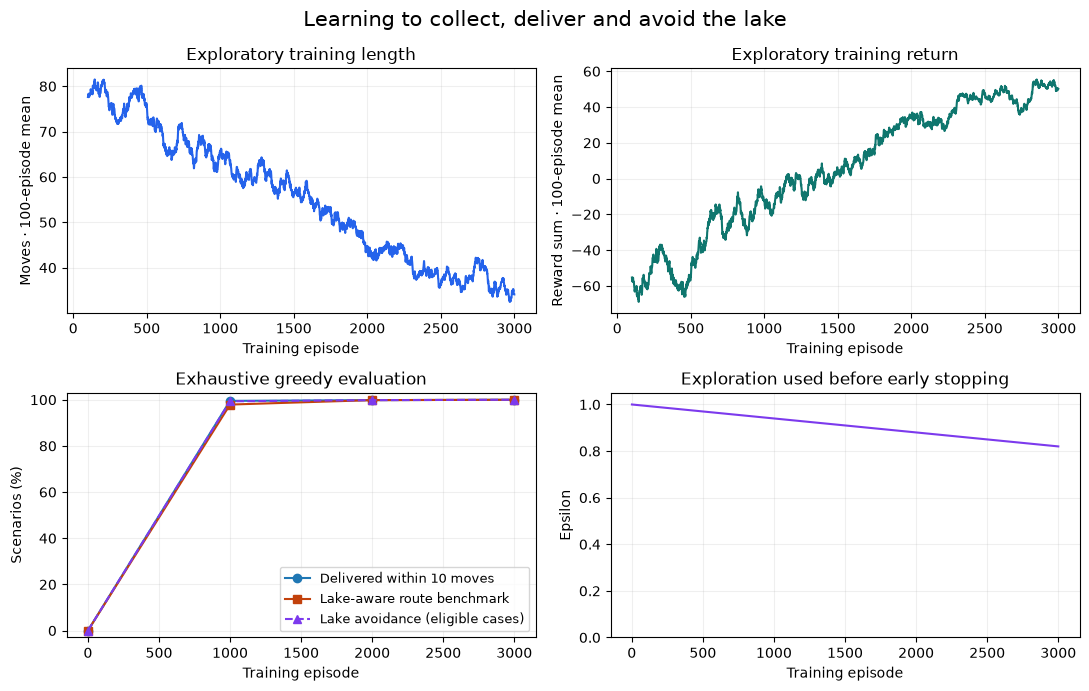

In [20]:
def moving_average(values, window=100):
    window = min(window, len(values))
    weights = np.ones(window) / window
    return np.convolve(np.asarray(values, dtype=float), weights, mode='valid')

window = min(100, trained_episodes)
smoothed_x = np.arange(window, trained_episodes + 1)
checkpoints = training_log['evaluation']
checked_x = [0] + [row['episode'] for row in checkpoints]
initial_pass = summary(untrained_records)['passed_10'] / (N ** 4) * 100
checked_success = [initial_pass] + [100 * row['passed_10'] / row['scenarios'] for row in checkpoints]
checked_optimal = [100 * summary(untrained_records)['optimal'] / (N ** 4)] + [
    100 * row['optimal'] / row['scenarios'] for row in checkpoints]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0, 0].plot(smoothed_x, moving_average(training_log['steps'], window), color='#2563eb')
axes[0, 0].set(title='Exploratory training length', ylabel='Moves · 100-episode mean')
axes[0, 1].plot(smoothed_x, moving_average(training_log['returns'], window), color='#0f766e')
axes[0, 1].set(title='Exploratory training return', ylabel='Reward sum · 100-episode mean')
axes[1, 0].plot(checked_x, checked_success, marker='o', label='Delivered within 10 moves')
axes[1, 0].plot(checked_x, checked_optimal, marker='s', label='Lake-aware route benchmark', color='#c2410c')
initial_summary = summary(untrained_records)
checked_avoidance = [100 * initial_summary['lake_avoidance_passed'] / initial_summary['lake_avoidance_scenarios']] + [
    100 * row['lake_avoidance_passed'] / row['lake_avoidance_scenarios'] for row in checkpoints]
axes[1, 0].plot(checked_x, checked_avoidance, marker='^', linestyle='--', label='Lake avoidance (eligible cases)', color='#7c3aed')
axes[1, 0].set(title='Exhaustive greedy evaluation', ylabel='Scenarios (%)', ylim=(-3, 103))
axes[1, 0].legend(fontsize=9)
axes[1, 1].plot(np.arange(1, trained_episodes + 1), training_log['epsilon'], color='#7c3aed')
axes[1, 1].set(title='Exploration used before early stopping', ylabel='Epsilon', ylim=(0, 1.05))
for ax in axes.flat:
    ax.set_xlabel('Training episode')
    ax.grid(alpha=0.2)
fig.suptitle('Learning to collect, deliver and avoid the lake', fontsize=15)
fig.tight_layout()
plt.show()


## Plot the worst route for each pickup location

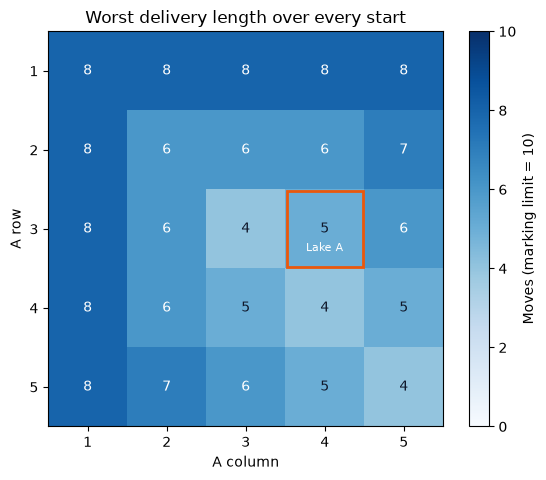

In [21]:
worst_by_A = np.zeros((N, N), dtype=int)
for row in final_records:
    ar, ac = row['pickup']
    worst_by_A[ar, ac] = max(worst_by_A[ar, ac], row['steps'])

fig, ax = plt.subplots(figsize=(5.8, 4.8))
picture = ax.imshow(worst_by_A, cmap='Blues', vmin=0, vmax=10)
for ar in range(N):
    for ac in range(N):
        ax.text(ac, ar, str(worst_by_A[ar, ac]), ha='center', va='center',
                color='white' if worst_by_A[ar, ac] >= 6 else '#0f172a')
ax.set_xticks(range(N), labels=range(1, N + 1))
ax.set_yticks(range(N), labels=range(1, N + 1))
ax.set(xlabel='A column', ylabel='A row', title='Worst delivery length over every start')
if LAKE is not None:
    ax.add_patch(plt.Rectangle((LAKE[1] - 0.48, LAKE[0] - 0.48), 0.96, 0.96, fill=False, edgecolor='#ea580c', linewidth=2))
    ax.text(LAKE[1], LAKE[0] + 0.28, 'Lake A', ha='center', fontsize=8, color='white')
fig.colorbar(picture, ax=ax, label='Moves (marking limit = 10)')
fig.tight_layout()
plt.show()


## Inspect the same route at different training stages

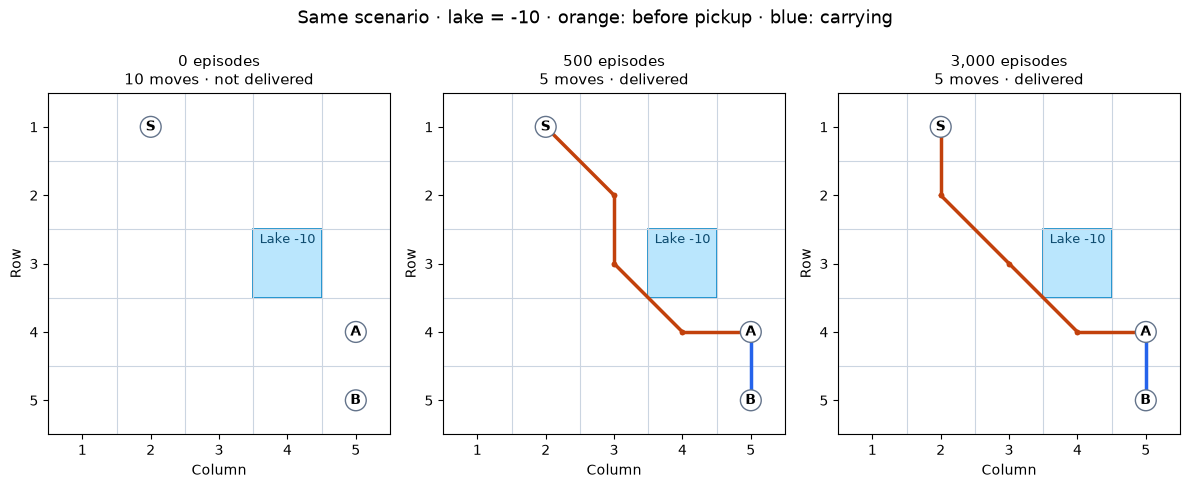

Final learned moves: ['down', 'down-right', 'down-right', 'right', 'down']
Displayed positions: [(1, 2), (2, 2), (3, 3), (4, 4), (4, 5), (5, 5)]
Final route lake entries: 0


In [22]:
def rollout(Q, start, pickup, n=5, target=None, cap=10, pickup_on_reset=False, lake=None):
    env = TransportGrid(n, target, cap, pickup_on_reset=pickup_on_reset, lake=lake)
    state = env.reset(start, pickup)
    trace = {'positions': [env.position], 'carrying': [env.carrying],
             'actions': [], 'rewards': []}
    while not (env.terminated or env.truncated):
        action = int(np.argmax(Q[state]))
        state, reward, _, _, _ = env.step(action)
        trace['positions'].append(env.position)
        trace['carrying'].append(env.carrying)
        trace['actions'].append(action)
        trace['rewards'].append(reward)
    trace['success'] = env.terminated
    trace['steps'] = env.steps
    trace['lake_entries'] = env.lake_entries
    return trace


def draw_grid(ax, n, lake=None):
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.set_xticks(range(n), labels=range(1, n + 1))
    ax.set_yticks(range(n), labels=range(1, n + 1))
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which='minor', color='#cbd5e1', linewidth=0.8)
    ax.tick_params(which='minor', length=0)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    if lake is not None:
        ax.add_patch(plt.Rectangle((lake[1] - 0.5, lake[0] - 0.5), 1, 1, facecolor='#bae6fd', edgecolor='#0284c7', linewidth=1.2))
        ax.text(lake[1], lake[0] - 0.30, 'Lake -10', ha='center', fontsize=9, color='#0c4a6e')


start_demo, pickup_demo = (0, max(0, N - 4)), (max(0, N - 2), N - 1)
stages = (0, 500, trained_episodes)
fig, axes = plt.subplots(1, 3, figsize=(12, 4.8))
for ax, episode in zip(axes, stages):
    trace = rollout(snapshots[episode], start_demo, pickup_demo, N, B,
                    pickup_on_reset=PICKUP_ON_RESET, lake=LAKE)
    draw_grid(ax, N, lake=LAKE)
    for i in range(1, len(trace['positions'])):
        previous, current = trace['positions'][i - 1:i + 1]
        colour = '#2563eb' if trace['carrying'][i - 1] else '#c2410c'
        ax.plot([previous[1], current[1]], [previous[0], current[0]],
                color=colour, linewidth=2.5, marker='o', markersize=3)
    for cell, label in ((start_demo, 'S'), (pickup_demo, 'A'), (B, 'B')):
        ax.text(cell[1], cell[0], label, ha='center', va='center', weight='bold',
                bbox={'facecolor': 'white', 'edgecolor': '#64748b', 'boxstyle': 'circle,pad=0.25'})
    outcome = 'delivered' if trace['success'] else 'not delivered'
    ax.set_title(f'{episode:,} episodes\n{trace["steps"]} moves · {outcome}', fontsize=11)
fig.suptitle('Same scenario · lake = -10 · orange: before pickup · blue: carrying', fontsize=13)
fig.tight_layout(rect=(0, 0.04, 1, 0.93))
plt.show()

learned_trace = rollout(frozen_Q, start_demo, pickup_demo, N, B,
                        pickup_on_reset=PICKUP_ON_RESET, lake=LAKE)
print('Final learned moves:', [ACTION_NAMES[a] for a in learned_trace['actions']])
print('Displayed positions:', [tuple(v + 1 for v in p) for p in learned_trace['positions']])
print('Final route lake entries:', learned_trace['lake_entries'])


## Check the alternative starting-on-A convention

In [23]:
alternative_Q, alternative_log, _ = train(
    seed=SEED, n=N, target=B, episodes=MAX_EPISODES,
    alpha=ALPHA, gamma=GAMMA,
    epsilon_start=EPSILON_START, epsilon_end=EPSILON_END,
    decay_episodes=DECAY_EPISODES, eval_every=EVALUATE_EVERY,
    pickup_on_reset=True, lake=LAKE
)
alternative_records = evaluate(alternative_Q, N, B, cap=max(100, 4 * N * N), pickup_on_reset=True, lake=LAKE)
alternative_metrics = summary(alternative_records)
nontrivial = [row for row in alternative_records if row['optimal_steps'] > 0]
print('Immediate pickup at reset:', alternative_metrics)
print('Episodes:', len(alternative_log['steps']))
print('Nontrivial scenarios passed:', sum(row['success'] for row in nontrivial), '/', len(nontrivial))
assert alternative_metrics['optimal'] == N ** 4
if N == 5:
    assert alternative_metrics['passed_10'] == 625
assert len(nontrivial) == N ** 4 - 1 and all(row['success'] for row in nontrivial)
assert len(alternative_log['steps']) < 20_000
notebook_training_total = sum(row['episodes'] for row in repeat_results) + len(alternative_log['steps'])
print('Total training episodes in this notebook, including repeats and reset comparison:',
      notebook_training_total)

assert alternative_metrics['avoidable_lake_entries'] == 0
assert alternative_metrics['lake_avoidance_passed'] == alternative_metrics['lake_avoidance_scenarios']
print('Alternative convention required / actual lake entries:',
      alternative_metrics['required_lake_entries'], '/', alternative_metrics['total_lake_entries'])


Immediate pickup at reset: {'scenarios': 625, 'passed_10': 625, 'successes': 625, 'max_steps': 8, 'mean_steps': 5.0784, 'optimal': 625, 'total_lake_entries': 24, 'required_lake_entries': 24, 'avoidable_lake_entries': 0, 'lake_avoidance_scenarios': 601, 'lake_avoidance_passed': 601}
Episodes: 2000
Nontrivial scenarios passed: 624 / 624
Total training episodes in this notebook, including repeats and reset comparison: 15000
Alternative convention required / actual lake entries: 24 / 24


In [ ]:
# FINAL CELL: animate saved policies at different training stages.
# Run all previous cells first. No training or Q-table updates occur here.
from matplotlib.animation import FuncAnimation

# Display the animation inside Jupyter with playback controls.
plt.rcParams["animation.html"] = "jshtml"

# Zero-based coordinates: change these to demonstrate another scenario.
animation_start = (0, max(0, N - 4))
animation_pickup = (max(0, N - 2), N - 1)
# To demonstrate collecting from the lake, use: animation_pickup = LAKE

animation_stages = sorted({0, 100, trained_episodes}.intersection(snapshots))

# Each saved policy attempts exactly the same task without exploration.
animation_traces = [
    rollout(
        snapshots[episode], animation_start, animation_pickup, N, B,
        cap=ASSESSMENT_LIMIT,
        pickup_on_reset=PICKUP_ON_RESET, lake=LAKE
    )
    for episode in animation_stages
]

animation_fig, animation_axes = plt.subplots(
    1, len(animation_stages),
    figsize=(4.2 * len(animation_stages), 5), squeeze=False
)
animation_fig.subplots_adjust(
    left=0.06, right=0.98, bottom=0.23, top=0.76, wspace=0.32
)
animation_fig.suptitle("Learning progress: the same transport task", fontsize=15)
animation_fig.text(
    0.5, 0.91,
    "Orange: before pickup | Blue: carrying | Green: delivered | Square: item",
    ha="center", fontsize=10
)


def update_animation(frame):
    for ax, episode, trace in zip(
        animation_axes.flat, animation_stages, animation_traces
    ):
        ax.clear()
        draw_grid(ax, N, lake=LAKE)

        # Completed episodes remain at their final position.
        step = min(frame, trace["steps"])
        finished = step == trace["steps"]
        delivered = finished and trace["success"]
        carrying = trace["carrying"][step]

        # Show only the route travelled up to this frame.
        for i in range(1, step + 1):
            previous, current = trace["positions"][i - 1:i + 1]
            colour = "#2563eb" if trace["carrying"][i - 1] else "#c2410c"
            ax.plot(
                [previous[1], current[1]], [previous[0], current[0]],
                color=colour, linewidth=2.5, alpha=0.7
            )

        # Keep location labels visible throughout the animation.
        for cell, label in (
            (animation_start, "S"), (animation_pickup, "A"), (B, "B")
        ):
            ax.text(
                cell[1], cell[0] + 0.30, label,
                ha="center", va="center", weight="bold", fontsize=10
            )

        # The item disappears from A after automatic pickup.
        if not carrying and not delivered:
            ax.plot(
                animation_pickup[1], animation_pickup[0],
                marker="s", color="#eab308", markersize=12, zorder=4
            )

        # Draw the agent at its current position.
        row, col = trace["positions"][step]
        agent_colour = (
            "#16a34a" if delivered else
            "#2563eb" if carrying else "#c2410c"
        )
        ax.plot(
            col, row, marker="o", markersize=15,
            color=agent_colour, markeredgecolor="white", zorder=5
        )

        status = (
            "Delivered" if delivered else
            "Step limit reached" if finished else
            "Carrying item" if carrying else "Going to A"
        )

        # Count entries so far; starting in the lake is not an entry.
        lake_entries = sum(
            previous != current and current == LAKE
            for previous, current in zip(
                trace["positions"][:step],
                trace["positions"][1:step + 1]
            )
        )
        reward_sum = sum(trace["rewards"][:step])

        ax.set_title(
            f"After {episode:,} training episodes\nMove {step}: {status}",
            fontsize=11
        )
        ax.text(
            0.5, -0.24,
            f"Reward sum: {reward_sum:.0f} | Lake entries: {lake_entries}",
            transform=ax.transAxes, ha="center", fontsize=10
        )


# Show the initial state, each move, and three extra final frames.
animation_frames = max(t["steps"] for t in animation_traces) + 4

learning_animation = FuncAnimation(
    animation_fig,
    update_animation,
    frames=animation_frames,
    interval=650,       # Milliseconds between moves.
    blit=False,
    repeat=False
)

plt.close(animation_fig)  # Prevent a duplicate static plot.


learning_animation